In [1]:
import pandas as pd
import numpy as np

# visualization
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier

from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV,StratifiedShuffleSplit

import warnings
warnings.filterwarnings('ignore')

In [2]:
train = pd.read_csv('../input/train.csv')
test = pd.read_csv('../input/test.csv')

In [3]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
titanic_data = pd.concat([train,test],keys=['train','test'])
train_labels = train['Survived']
titanic_data.head()

Age Cabin Embarked     Fare  \
train 0  22.0   NaN        S   7.2500   
      1  38.0   C85        C  71.2833   
      2  26.0   NaN        S   7.9250   
      3  35.0  C123        S  53.1000   
      4  35.0   NaN        S   8.0500   

                                                      Name  Parch  \
train 0                            Braund, Mr. Owen Harris      0   
      1  Cumings, Mrs. John Bradley (Florence Briggs Th...      0   
      2                             Heikkinen, Miss. Laina      0   
      3       Futrelle, Mrs. Jacques Heath (Lily May Peel)      0   
      4                           Allen, Mr. William Henry      0   

         PassengerId  Pclass     Sex  SibSp  Survived            Ticket  
train 0            1       3    male      1       0.0         A/5 21171  
      1            2       1  female      1       1.0          PC 17599  
      2            3       3  female      0       1.0  STON/O2. 3101282  
      3            4       1  female      1       1.0            113803  
      4            5       3    male      0       0.0            373450

In [6]:
train.info()
print('_'*40)
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
PassengerId    891 non-null int64
Survived       891 non-null int64
Pclass         891 non-null int64
Name           891 non-null object
Sex            891 non-null object
Age            714 non-null float64
SibSp          891 non-null int64
Parch          891 non-null int64
Ticket         891 non-null object
Fare           891 non-null float64
Cabin          204 non-null object
Embarked       889 non-null object
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
________________________________________
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
PassengerId    418 non-null int64
Pclass         418 non-null int64
Name           418 non-null object
Sex            418 non-null object
Age            332 non-null float64
SibSp          418 non-null int64
Parch          418 non-null int64
Ticket         418 non-null

In [7]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
train.describe(include=['O'])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Paulner, Mr. Uscher",male,347082,B96 B98,S
freq,1,577,7,4,644


In [9]:
train[['Pclass', 'Survived']].groupby(['Pclass'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


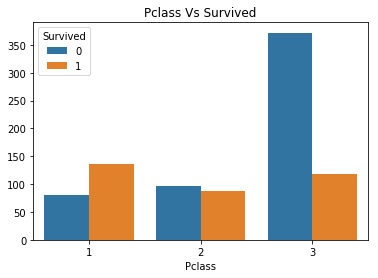

In [10]:
sns.countplot(x='Pclass',hue='Survived',data = train)
plt.title("Pclass Vs Survived")
plt.ylabel("")
plt.show()

In [11]:
train[["Sex", "Survived"]].groupby(['Sex'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,Sex,Survived
0,female,0.742038
1,male,0.188908


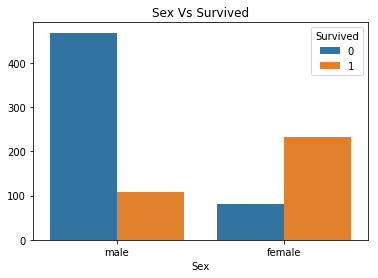

In [12]:
sns.countplot(x='Sex',hue='Survived',data = train)
plt.title("Sex Vs Survived")
plt.ylabel("")
plt.show()

In [13]:
train[["SibSp", "Survived"]].groupby(['SibSp'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,SibSp,Survived
1,1,0.535885
2,2,0.464286
0,0,0.345395
3,3,0.250000
4,4,0.166667
5,5,0.000000
6,8,0.000000


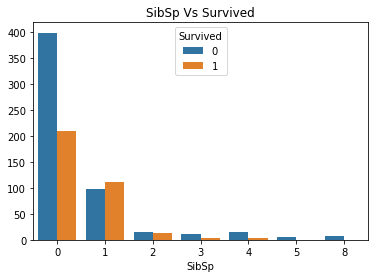

In [14]:
sns.countplot(x='SibSp',hue='Survived',data = train)
plt.title("SibSp Vs Survived")
plt.ylabel("")
plt.show()

In [15]:
train[["Parch", "Survived"]].groupby(['Parch'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,Parch,Survived
3,3,0.600000
1,1,0.550847
2,2,0.500000
0,0,0.343658
5,5,0.200000
4,4,0.000000
6,6,0.000000


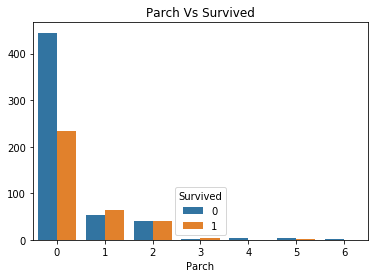

In [16]:
sns.countplot(x='Parch',hue='Survived',data = train)
plt.title("Parch Vs Survived")
plt.ylabel("")
plt.show()

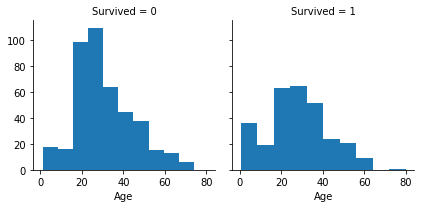

In [17]:
g = sns.FacetGrid(train,col='Survived')
g.map(plt.hist,'Age')
plt.show()

In [18]:
train_df = train.drop(['PassengerId'], axis=1)

test_df = test.copy()
combine = [train_df, test_df]

In [19]:
for dataset in combine:
    dataset['Title'] = dataset.Name.str.extract(' ([A-Za-z]+)\.', expand=False)

In [20]:
for dataset in combine:
    dataset['Title'] = dataset['Title'].replace(['Lady', 'Countess','Capt', 'Col',\
     'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Unknown')

    dataset['Title'] = dataset['Title'].replace('Mlle', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Ms', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Mme', 'Mrs')
    
train_df[['Title', 'Survived']].groupby(['Title'], as_index=False).mean()

,Title,Survived
0,Master,0.575000
1,Miss,0.702703
2,Mr,0.156673
3,Mrs,0.793651
4,Unknown,0.347826


In [21]:
title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Unknown": 5}
for dataset in combine:
    dataset['Title'] = dataset['Title'].map(title_mapping)

In [22]:
train_df = train_df.drop(['Ticket', 'Cabin','Name'], axis=1)

test_df = test_df.drop(['Ticket', 'Cabin','Name'], axis=1)
combine = [train_df, test_df]

In [23]:
mean_age = train_df['Age'].mean()
std_age = test_df['Age'].std()
    
for dataset in combine:
    dataset['Sex'] = dataset['Sex'].map( {'female': 1, 'male': 0} ).astype(int)
       
    null_age_count = dataset['Age'].isnull().sum()
    random_age = np.random.randint((mean_age - std_age),(mean_age + std_age),size=null_age_count)
    
    age_guess = dataset['Age'].copy()
    age_guess[np.isnan(age_guess)] = random_age
    
    dataset['Age'] = age_guess
    dataset['Age'] = dataset['Age'].astype(int)
    
combine = [train_df, test_df]

In [24]:
for dataset in combine:   
    
    dataset.loc[ dataset['Age'] <= 16, 'Age'] = 0
    dataset.loc[(dataset['Age'] > 16) & (dataset['Age'] <= 32), 'Age'] = 1
    dataset.loc[(dataset['Age'] > 32) & (dataset['Age'] <= 48), 'Age'] = 2
    dataset.loc[(dataset['Age'] > 48) & (dataset['Age'] <= 64), 'Age'] = 3
    dataset.loc[ dataset['Age'] > 64, 'Age'] = 4


In [25]:
for dataset in combine:
    dataset['FamilySize'] = dataset['SibSp'] + dataset['Parch'] + 1

for dataset in combine:
    size = []
    for col in dataset.FamilySize:
        if col > 1:
            size.append(0)
        else:
            size.append(1)
            
    dataset['Isalone'] = size
train_df = train_df.drop(['Parch', 'SibSp', 'FamilySize'], axis=1)
test_df = test_df.drop(['Parch', 'SibSp', 'FamilySize'], axis=1)
combine = [train_df, test_df]


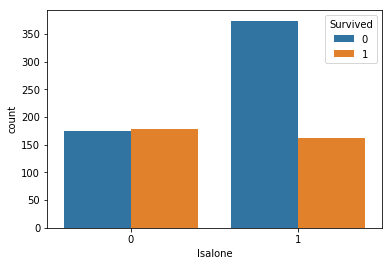

In [26]:
sns.countplot(x='Isalone',hue='Survived',data=train_df);

In [27]:
for dataset in combine:
    dataset['Embarked']  = dataset['Embarked'].fillna('S')
    dataset['Embarked'] = dataset['Embarked'].map( {'S': 0, 'C': 1, 'Q': 2} ).astype(int)
    
train_df[['Embarked', 'Survived']].groupby(['Embarked'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,Embarked,Survived
1,1,0.553571
2,2,0.389610
0,0,0.339009


In [28]:
for dataset in combine:
    dataset['Fare'] = dataset['Fare'].fillna(0)
    dataset['Fare'] = dataset['Fare'].astype(int)    
    
    dataset.loc[ dataset['Fare'] <= 7.91, 'Fare'] = 0
    dataset.loc[(dataset['Fare'] >7.91) & (dataset['Fare']<=14.454),'Fare'] = 1
    dataset.loc[(dataset['Fare'] > 14.454) & (dataset['Fare'] <= 31), 'Fare']   = 2
    dataset.loc[ dataset['Fare'] > 31, 'Fare'] = 3

combine = [train_df, test_df]    
train_df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Title,Isalone
0,0,3,0,1,0,0,1,0
1,1,1,1,2,3,1,3,0
2,1,3,1,1,0,0,2,1
3,1,1,1,2,3,0,3,0
4,0,3,0,2,1,0,1,1


In [29]:
X = train_df.drop("Survived", axis=1)
Y = train_df["Survived"]

X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=0.3)

Final_test  = test_df.drop("PassengerId", axis=1).values


In [30]:
X_train.shape,y_train.shape,X_test.shape,y_test.shape

((623, 7), (623,), (268, 7), (268,))

In [31]:
X = train_df.drop(['Survived','Isalone'], axis=1).values
Y = train_df['Survived'].values

X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=0.3)

Final_test  = test_df.drop(['Isalone','PassengerId'], axis=1).values

In [32]:
lr =  LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

lr_acc = round(accuracy_score(lr_pred, y_test), 3)
print('Logistic Regression accuracy: ',lr_acc)

Logistic Regression accuracy:  0.784


In [33]:
dc =  DecisionTreeClassifier()
dc.fit(X_train, y_train)
dc_pred = dc.predict(X_test)

dc_acc = round(accuracy_score(dc_pred, y_test), 3)
print('Decision Tree Accuracy: ',dc_acc)

Decision Tree Accuracy:  0.851


In [34]:
rfc = RandomForestClassifier(n_estimators=400,oob_score=True,criterion='entropy',random_state=1)
rfc.fit(X_train, y_train)
rfc_pred = rfc.predict(X_test)

rfc_acc = round(accuracy_score(rfc_pred, y_test), 3)
print('Random Forest Classifier Accuracy: ',rfc_acc)

Random Forest Classifier Accuracy:  0.854


In [35]:
svc = SVC()
svc.fit(X_train, y_train)
svc_pred = svc.predict(X_test)

svc_acc = round(accuracy_score(svc_pred, y_test), 3)
print('Support Vector Machine Accuracy: ',svc_acc)

Support Vector Machine Accuracy:  0.806


In [36]:
from sklearn.ensemble import BaggingClassifier
Bagg_estimators = [10,25,50,75,100,150,250];
cv = StratifiedShuffleSplit(n_splits=10, test_size=.33, random_state=15)

parameters = {'n_estimators':Bagg_estimators }
gridBG = GridSearchCV(BaggingClassifier(base_estimator= None, ## If None, then the base estimator is a decision tree.
                                      bootstrap_features=False),
                                 param_grid=parameters,
                                 cv=cv,
                                 n_jobs = -1)
gridBG.fit(X_train,y_train)

print ('Bagging classifier best score: ', gridBG.best_score_)
print (gridBG.best_params_)
print (gridBG.best_estimator_)

bagging = gridBG.best_estimator_

bagging_pred = bagging.predict(X_test)

bagging_acc = round(accuracy_score(bagging_pred, y_test), 3)
print('AdaBoost Accuracy: ',bagging_acc)

Bagging classifier best score:  0.8048543689320389
{'n_estimators': 25}
BaggingClassifier(base_estimator=None, bootstrap=True, bootstrap_features=False,
                  max_features=1.0, max_samples=1.0, n_estimators=25,
                  n_jobs=None, oob_score=False, random_state=None, verbose=0,
                  warm_start=False)
AdaBoost Accuracy:  0.858


In [37]:

cv = StratifiedShuffleSplit(n_splits=10,test_size=0.3,random_state=15)

n_estimators = [100,140,145,150,160, 170,175,180,185];

learning_rate = [0.1,1,0.01,0.5]

parameters = {'n_estimators':n_estimators,'learning_rate':learning_rate}

gridAda = GridSearchCV(AdaBoostClassifier(base_estimator=None),param_grid=parameters,cv=cv,n_jobs=-1)

gridAda.fit(X_train,y_train)

print("Ada Boost Score:",gridAda.best_score_)
print(gridAda.best_params_)

adaBoost = gridAda.best_estimator_

#print('Ada Boost estimator score:',adaBoost.score(X_test,y_test))

adaBoost_pred = adaBoost.predict(X_test)

adaBoost_acc = round(accuracy_score(adaBoost_pred, y_test), 3)
print('AdaBoost Accuracy: ',adaBoost_acc)

Ada Boost Score: 0.795187165775401
{'learning_rate': 0.1, 'n_estimators': 145}
AdaBoost Accuracy:  0.784


In [38]:
gbc = GradientBoostingClassifier()
gbc.fit(X_train,y_train)

gbc_pred = gbc.predict(X_test)


gradient_acc = round(accuracy_score(gbc_pred, y_test), 3)
print('Gradient Boosting accuracy: ',gradient_acc)

Gradient Boosting accuracy:  0.821


In [39]:
clf = [lr, dc, rfc, svc,bagging,adaBoost,gbc]

for clf, label in zip([lr, dc, rfc, svc,bagging,adaBoost,gbc], ['Logistic Regression','Decision Tree','Random Forest', 'SVC','Bagging','AdaBoost','Gradient Boost']):
    scores = cross_val_score(clf, X_test, y_test, cv=10, scoring='accuracy')
    print("Accuracy: %0.2f (+/- %0.2f) [%s]" % (scores.mean(), scores.std(), label))

Accuracy: 0.80 (+/- 0.08) [Logistic Regression]
Accuracy: 0.81 (+/- 0.06) [Decision Tree]
Accuracy: 0.81 (+/- 0.06) [Random Forest]
Accuracy: 0.80 (+/- 0.07) [SVC]
Accuracy: 0.80 (+/- 0.07) [Bagging]
Accuracy: 0.78 (+/- 0.08) [AdaBoost]
Accuracy: 0.83 (+/- 0.05) [Gradient Boost]


In [40]:
eclf = VotingClassifier(estimators=[('Logistic Regression',lr),('Decision Tree',dc),('Random Forests', rfc),  ('SVC', svc), ('Bagging', bagging), ('AdaBoost', adaBoost), ('Gradient Boosting', gbc)], voting='hard')
eclf.fit(X_train,y_train)
vote_pred = eclf.predict(X_test)
voting_acc = round(accuracy_score(vote_pred,y_test),4)

print('Voting accuracy of the combined classifiers: ',voting_acc)

Voting accuracy of the combined classifiers:  0.8321


In [41]:
Y_Pred = eclf.predict(Final_test)

In [42]:
submission = pd.DataFrame({
        "PassengerId": test_df["PassengerId"],
        "Survived": Y_Pred
    })
submission.to_csv('my_titanic_submission_voting.csv', index=False)